#### [LO 1, LO 2 – 30 Points] Buatlah pemodelan machine learning dengan menerapkan pipeline yang mencakupseluruh proses preprocessing data sebelum melakukan klasifikasi. Lakukan pelatihan menggunakan dua algoritma berbeda, kemudian bandingkan performanya dan pilih algoritma terbaik untuk disimpan dalam format pickle. Pastikan seluruh rangkaian proses termasuk laporan klasifikasi dari masing-masing model terdokumentasi lengkap dalam file .ipynb.

#### DESKRIPSI DATASET


---



Dataset ObesityDataSet:
1.   Gender = Laki-laki atau Wanita
2.   Age = Usia seseorang dalam tahun
3. Height = Tinggi dalam meter
4. Weight = Berat dalam kilogram
5. family_history_with_overweight = Apakah orang tersebut memiliki riwayat keluarga dengan kelebihan berat badan
6. FAVC = Jika orang tersebut sering mengonsumsi makanan berkalori tinggi (ya/tidak)
7. FCVC = Frekuensi konsumsi sayuran (skala dari 1 hingga 3)
8. NCP = Jumlah makanan utama per hari
9. CAEC = Frekuensi mengonsumsi makanan di antara waktu makan  (Tidak pernah, Kadang-kadang, Sering, Selalu)
10. SMOKE = Apakah orang tersebut merokok (ya/tidak)
11. CH2O = Asupan air harian (skala dari 1 hingga 3)
12. SCC = Jika orang tersebut memantau asupan kalori mereka (ya/tidak)
13. FAF = Frekuensi aktivitas fisik (skala dari 0 hingga 3)
14. TUE = Waktu yang dihabiskan untuk menggunakan teknologi (skala dari 0 hingga 3)
15. CALC = Frekuensi konsumsi alkohol (Tidak pernah, Kadang-kadang, Sering, Selalu)
16. MTRANS = Moda transportasi utama (Mobil, Sepeda, Sepeda Motor, Transportasi Umum, Jalan Kaki)
17. NObeyesedad = Tingkat obesitas (Insufficient Weight, Normal Weight, Overweight Level I, Overweight
18. Level II, Obesity Type I, Obesity Type II, Obesity Type III)

Anda bekerja sebagai developer di sebuah klinik kesehatan yang berfokus pada pencegahan obesitas. Klinik ini ingin melakukan pendekatan yang lebih personal dan proaktif kepada masyarakat yang memiliki risiko tinggi mengalami obesitas berat, agar bisa diberikan edukasi atau intervensi lebih awal. Manajemen ingin mengembangkan sistem prediksi berbasis data yang bisa mengklasifikasikan tingkat obesitas seseorang berdasarkan gaya hidup dan kebiasaan sehari-hari. Dengan begitu, kampanye kesehatan dapat difokuskan pada individu yang berada pada tingkat risiko tinggi.



In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Mengimport library yang akan dipakai

In [185]:
df=pd.read_csv('ObesityDataSet2.csv')
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,24,1.58,65.29,yes,no,2.03,2.74,Sometimes,no,2.00,no,1.28,1.019,no,Public_Transportation,Overweight_Level_II
1,Male,23,1.65,66.00,no,no,3.00,3.00,Sometimes,no,2.00,no,3.00,0.000,no,Public_Transportation,Normal_Weight
2,Female,21,1.69,51.26,yes,yes,3.00,3.18,Frequently,no,1.91,no,0.48,0.625,no,Public_Transportation,Insufficient_Weight
3,Female,22,1.69,65.00,yes,yes,2.00,3.00,Sometimes,no,2.00,no,1.00,1.000,Sometimes,Public_Transportation,Normal_Weight
4,Female,23,1.61,82.64,yes,yes,2.96,1.00,Sometimes,no,2.98,no,0.74,2.000,Sometimes,Public_Transportation,Obesity_Type_I


menampilkan 5 baris teratas dari setiap kolom dalam dataset

In [186]:
#melihat shape dataset
df.shape

(1056, 17)

menampilkan dimensi yang dimiliki oleh dataset, yaitu sebesar : 1056 row dan 17 columns.

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          1056 non-null   object 
 1   Age                             1056 non-null   object 
 2   Height                          1056 non-null   float64
 3   Weight                          1056 non-null   float64
 4   family_history_with_overweight  1056 non-null   object 
 5   FAVC                            1056 non-null   object 
 6   FCVC                            1019 non-null   float64
 7   NCP                             1056 non-null   float64
 8   CAEC                            1056 non-null   object 
 9   SMOKE                           1056 non-null   object 
 10  CH2O                            1056 non-null   float64
 11  SCC                             1056 non-null   object 
 12  FAF                             10

In [188]:
df.describe()

,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,1056.000000,1056.000000,1019.000000,1056.000000,1056.000000,1056.000000,1056.000000
mean,1.700066,86.497633,2.421374,2.651686,1.998002,0.987528,0.642227
std,0.091560,26.181219,0.537591,0.804457,0.612930,0.850452,0.615533
min,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.630000,66.000000,2.000000,2.525000,1.530000,0.110000,0.000000
50%,1.700000,82.635000,2.390000,3.000000,2.000000,1.000000,0.583000
75%,1.760000,107.965000,3.000000,3.000000,2.442500,1.602500,1.000000
max,1.950000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [189]:
#melihat kolom mana saja yang termasuk data numerik dan kategorik
cat_cols = []
num_cols = []

for i in df.columns:
    if 'int' in str(df[i].dtype) or 'float' in str(df[i].dtype):
        num_cols.append(i)
    else:
        cat_cols.append(i)

print(f'Categorical: {cat_cols}')
print(f'Numeric: {num_cols}')

Categorical: ['Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
Numeric: ['Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


In [190]:
# Cek unique values dari kolom 'Gender'
print(df['Gender'].unique())
# Cek unique values dari kolom 'CAEC', 'CALC', dan 'MTRANS'
print(df['CAEC'].unique())
print(df['CALC'].unique())
print(df['MTRANS'].unique())

['Female' 'Male']
['Sometimes' 'Frequently' 'no' 'Always']
['no' 'Sometimes' 'Frequently' 'Always']
['Public_Transportation' 'Bike' nan 'Automobile' 'Motorbike' 'Walking']


In [191]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,37
NCP,0
CAEC,0
SMOKE,0


In [192]:
print(df['FCVC'].value_counts())
print(df['MTRANS'].value_counts())

FCVC
3.00    323
2.00    297
1.00     17
2.88      9
2.05      9
       ... 
2.95      1
1.52      1
1.28      1
2.55      1
2.64      1
Name: count, Length: 147, dtype: int64
MTRANS
Public_Transportation    773
Automobile               216
Walking                   29
Motorbike                  8
Bike                       4
Name: count, dtype: int64


In [193]:
# Imputasi kolom FAVC
df['FCVC'] = df['FCVC'].fillna(df['FCVC'].mean())

# Imputasi kolom SMOKE
df['MTRANS'] = df['MTRANS'].fillna(df['MTRANS'].mode()[0])

melakukan inputasi kedalam kolom yang memiliki missing value agar value di replace menjadi mean untuk kolom numerik dan direplace menjadi modus untuk kolom kategorik.

In [194]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


memastikan apakah masih ada missing value yg tersisa setelah melakukan inputasi data.

In [195]:
df['Age'] = df['Age'].str.extract(r'(\d+)').astype(float)

In [196]:
df.nunique()

,0
Gender,2
Age,36
Height,47
Weight,715
family_history_with_overweight,2
FAVC,2
FCVC,148
NCP,194
CAEC,4
SMOKE,2


menampilkan unique value dari setaip kolom dalam dataset

/tmp/ipython-input-197-4102593445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')
/tmp/ipython-input-197-4102593445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')
/tmp/ipython-input-197-4102593445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel')
/tmp/ipython-input-197-4102593445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and

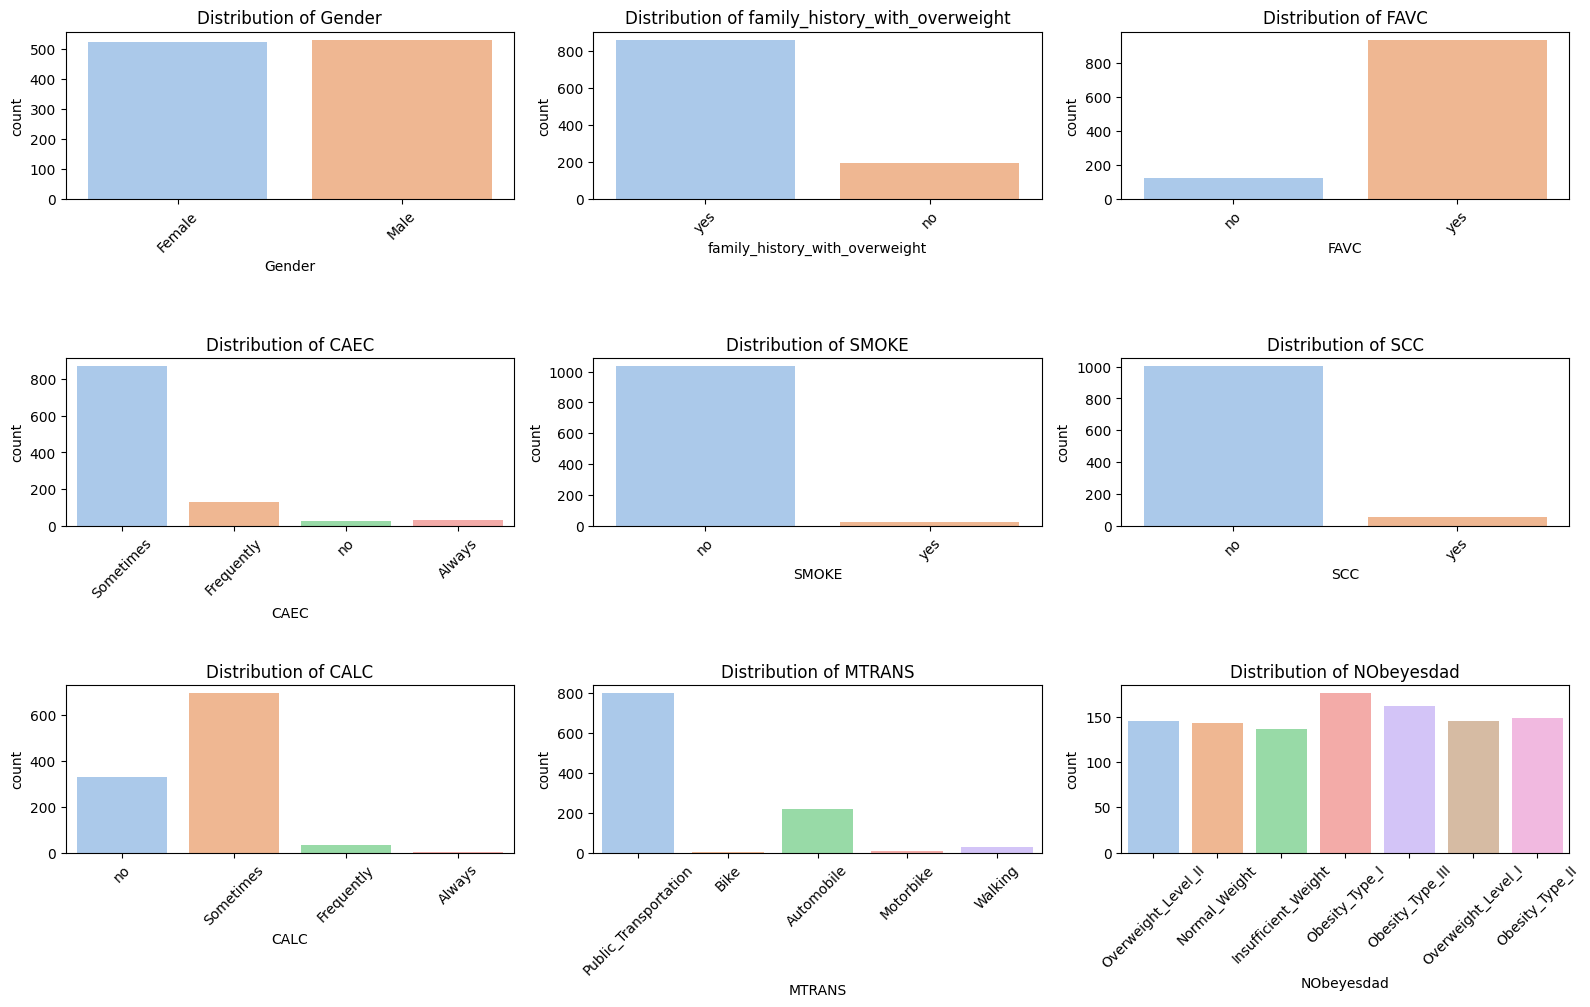

In [197]:
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
plt.figure(figsize=(16, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 3, i)  # grid 4x3 (maksimal 12 plot)
    sns.countplot(data=df, x=col, palette='pastel')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

meklihat visualisasi kategorik sekaligus cek apakah ada outlier dari kolom kategorik : Gender, Age, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, NObeyesdad

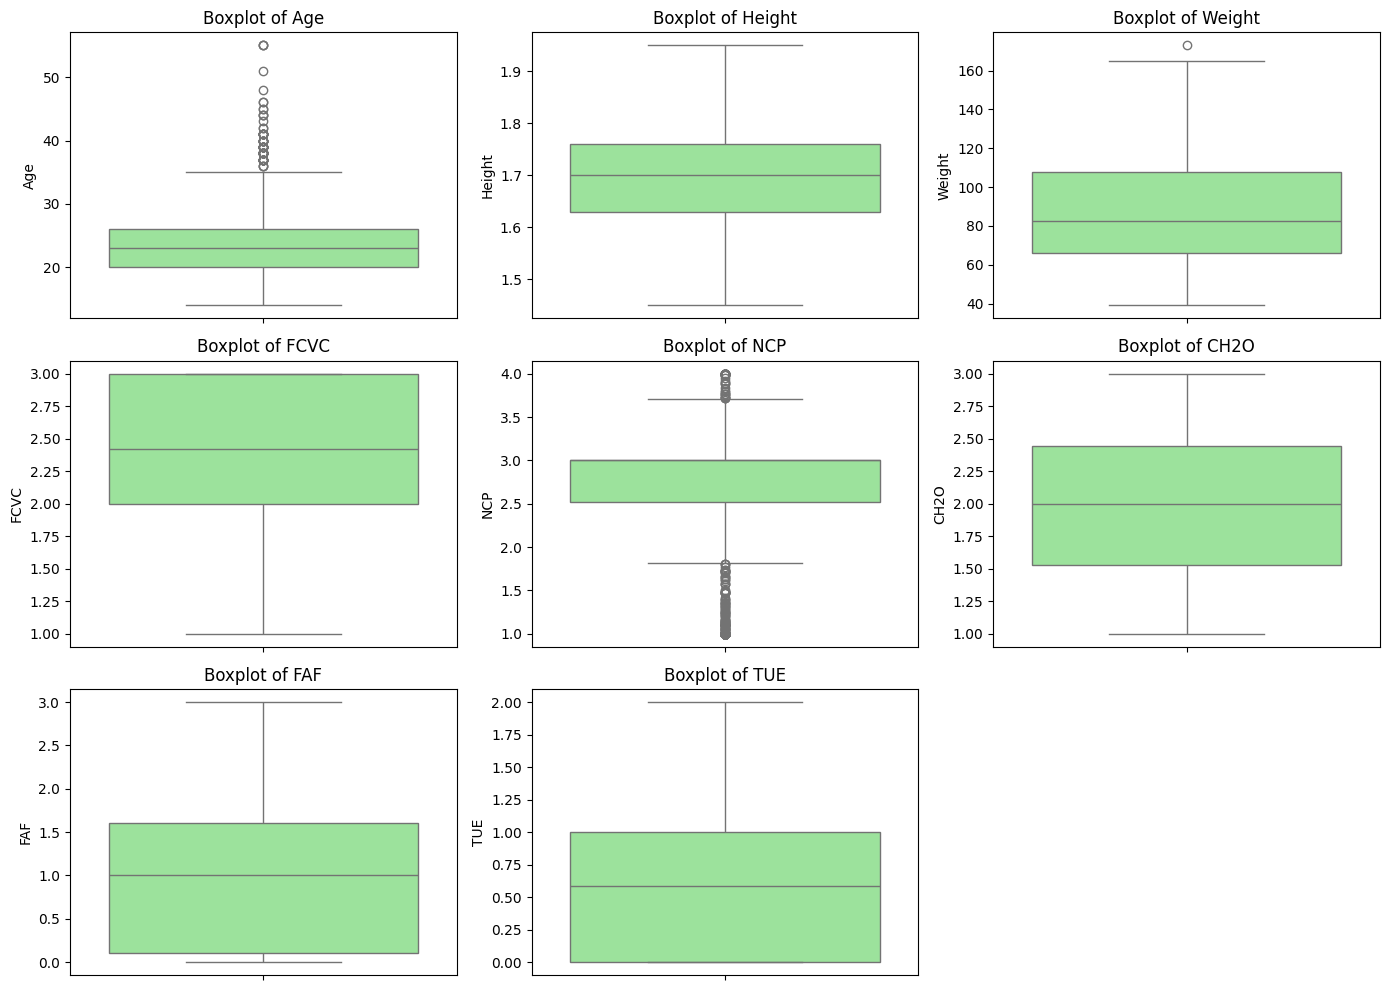

In [198]:
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
plt.figure(figsize=(14, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)  # grid 3x3
    sns.boxplot(data=df, y=col, color='lightgreen')  # ganti x=col jadi y=col
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

melihat visualisasi numerik dan melihat apakah ada outlier pada kolom : Height, Weight, FCVC, NCP, CH2O, FAF, TUE

In [199]:
def detect_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

# Outlier di Age
print("Outlier di Age:", detect_outliers(df['Age']).tolist())

# Outlier di NCP
print("Outlier di NCP:", detect_outliers(df['NCP']).tolist())

# Outlier di Weight
print("Outlier di Weight:", detect_outliers(df['Weight']).tolist())

Outlier di Age: [38.0, 44.0, 39.0, 41.0, 41.0, 38.0, 42.0, 39.0, 40.0, 38.0, 38.0, 38.0, 38.0, 38.0, 37.0, 38.0, 40.0, 38.0, 37.0, 40.0, 37.0, 38.0, 44.0, 38.0, 40.0, 36.0, 38.0, 39.0, 38.0, 38.0, 37.0, 55.0, 55.0, 41.0, 37.0, 46.0, 41.0, 36.0, 41.0, 39.0, 39.0, 41.0, 38.0, 40.0, 39.0, 45.0, 36.0, 38.0, 42.0, 40.0, 46.0, 38.0, 38.0, 43.0, 39.0, 41.0, 51.0, 45.0, 48.0, 37.0, 40.0, 38.0, 39.0, 38.0, 39.0, 38.0, 39.0, 41.0, 38.0, 41.0, 39.0, 38.0, 44.0, 37.0, 40.0, 55.0, 37.0, 37.0, 37.0, 37.0]
Outlier di NCP: [1.0, 1.0, 4.0, 1.8, 1.1, 1.47, 1.74, 4.0, 4.0, 1.32, 1.71, 1.0, 1.26, 1.0, 1.01, 1.0, 1.0, 1.0, 1.47, 4.0, 1.15, 1.0, 1.0, 1.0, 1.11, 3.89, 1.0, 1.73, 1.25, 1.0, 3.99, 1.0, 1.17, 1.0, 1.17, 1.36, 1.0, 3.95, 1.0, 1.0, 1.35, 1.0, 1.0, 1.32, 1.05, 4.0, 1.0, 1.0, 1.0, 1.0, 3.88, 4.0, 1.0, 1.03, 3.76, 1.0, 1.0, 3.72, 1.0, 1.48, 3.8, 1.3, 1.0, 1.0, 1.0, 1.7, 1.0, 1.0, 1.14, 1.0, 1.49, 1.39, 1.0, 1.0, 1.0, 1.0, 1.01, 1.0, 3.99, 1.0, 1.81, 1.0, 1.16, 1.0, 1.0, 1.0, 3.76, 3.79, 1.57, 1.31, 

mendeteksi nilai outlier yang ada dalam kolom Age, NCP dan Weight.

In [200]:
from sklearn.preprocessing import RobustScaler

scaler_ncp = RobustScaler()
df['NCP_scaled'] = scaler_ncp.fit_transform(df[['NCP']])

scaler_weight = RobustScaler()
df['Weight_scaled'] = scaler_weight.fit_transform(df[['Weight']])

Melakukan scaling (penyesuaian skala) pada kolom NCP dan Weight menggunakan RobustScaler, agar data lebih stabil terhadap outlier.

### PREPROCESSING

In [201]:
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
                    'SMOKE', 'SCC', 'CALC', 'MTRANS']
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
target_col = 'NObeyesdad'

In [202]:
for col in categorical_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

In [203]:
# Setelah standarisasi, periksa kembali unique values
print("Unique values after standardization:")
print(df['Gender'].unique())
print(df['CAEC'].unique())
print(df['CALC'].unique())
print(df['MTRANS'].unique())

Unique values after standardization:
['female' 'male']
['sometimes' 'frequently' 'no' 'always']
['no' 'sometimes' 'frequently' 'always']
['public_transportation' 'bike' 'automobile' 'motorbike' 'walking']


In [204]:
X = df[categorical_cols + numerical_cols]
le = LabelEncoder()
y_encoded = le.fit_transform(df[target_col]) # LabelEncoder dilatih dengan data asli

In [205]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)

In [206]:
# Imputer harus berjalan sebelum encoder
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputasi NaN/missing values
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)) # Encoding
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, categorical_cols),
    ('num', num_pipeline, numerical_cols)
])

In [207]:
# Create pipeline function
def create_model_pipeline(model):
    return Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', model)
    ])

### MODELLING

##### XGBOOST MODEL

In [208]:
pipeline_xgb = create_model_pipeline(XGBClassifier(use_label_encoder=False, eval_metric='logloss'))

In [209]:
pipeline_xgb.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:51:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC', 'MTRANS']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   Simpl...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [210]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n🎯 Model: {model_name}")
    print("Accuracy:", round(acc * 100, 2), "%")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [211]:
evaluate_model(pipeline_xgb, X_test, y_test, "XGBoost")

xgb_model = pipeline_xgb.named_steps['classifier']
feature_names = pipeline_xgb.named_steps['preprocessing'].transformers_[0][2] + pipeline_xgb.named_steps['preprocessing'].transformers_[1][2]

importances = xgb_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:5]

print("5 Fitur penting teratas:")
for i in top_idx:
    print(f"{feature_names[i]}: {importances[i]:.4f}")


🎯 Model: XGBoost
Accuracy: 93.62 %
Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        54
           1       0.91      0.86      0.88        57
           2       0.94      0.93      0.94        71
           3       0.95      0.98      0.97        60
           4       1.00      0.98      0.99        65
           5       0.93      0.90      0.91        58
           6       0.90      0.90      0.90        58

    accuracy                           0.94       423
   macro avg       0.93      0.94      0.93       423
weighted avg       0.94      0.94      0.94       423

Confusion Matrix:
[[54  0  0  0  0  0  0]
 [ 5 49  0  0  0  1  2]
 [ 0  0 66  1  0  1  3]
 [ 0  0  1 59  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  4  1  0  0 52  1]
 [ 0  1  2  1  0  2 52]]
5 Fitur penting teratas:
Gender: 0.4767
Weight: 0.1474
Height: 0.0582
CAEC: 0.0511
CALC: 0.0406


Model XGBoost menunjukkan performa yang sangat baik dengan akurasi mencapai 93.62%. Semua kelas berhasil dikenali dengan tingkat precision, recall, dan f1-score yang tinggi, menandakan model ini cukup akurat dan seimbang dalam melakukan klasifikasi. Dari analisis fitur penting, variabel seperti Gender, Weight, CAEC, Height, dan CALC menjadi faktor utama yang memengaruhi prediksi model. Hal ini menunjukkan bahwa faktor-faktor tersebut memiliki peran besar dalam menentukan hasil klasifikasi obesitas pada dataset ini. Secara keseluruhan, XGBoost memberikan hasil yang andal dan dapat dipercaya untuk tugas ini.


##### Random Forest Model

In [212]:
pipeline_rf = create_model_pipeline(RandomForestClassifier(random_state=42))

In [213]:
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC', 'MTRANS']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [214]:
evaluate_model(pipeline_rf, X_test, y_test, "Random Forest")

rf_model = pipeline_rf.named_steps['classifier']
feature_names = pipeline_rf.named_steps['preprocessing'].transformers_[0][2] + pipeline_rf.named_steps['preprocessing'].transformers_[1][2]
import numpy as np

importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:5]

print("5 Fitur penting teratas:")
for i in top_idx:
    print(f"{feature_names[i]}: {importances[i]:.4f}")


🎯 Model: Random Forest
Accuracy: 90.07 %
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93        54
           1       0.74      0.93      0.82        57
           2       0.94      0.93      0.94        71
           3       0.95      0.98      0.97        60
           4       0.98      0.98      0.98        65
           5       0.88      0.84      0.86        58
           6       0.87      0.71      0.78        58

    accuracy                           0.90       423
   macro avg       0.90      0.90      0.90       423
weighted avg       0.91      0.90      0.90       423

Confusion Matrix:
[[49  5  0  0  0  0  0]
 [ 2 53  0  0  0  1  1]
 [ 0  0 66  1  0  1  3]
 [ 0  0  0 59  1  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  7  0  0  0 49  2]
 [ 0  7  4  1  0  5 41]]
5 Fitur penting teratas:
Weight: 0.3440
Height: 0.0904
FCVC: 0.0866
Age: 0.0858
Gender: 0.0625


Model Random Forest menunjukkan performa yang sangat baik dengan akurasi sebesar 90.07%. Semua kelas memiliki precision, recall, dan f1-score di atas 78%, dengan beberapa kelas bahkan mencapai nilai di atas 90%, seperti kelas 2, 3, dan 4 yang menunjukkan hasil hampir sempurna. Macro average f1-score sebesar 0.92 menandakan model ini sangat seimbang dalam mengklasifikasikan seluruh kelas. Dari analisis fitur penting, variabel **Weight**, **Height**, **Age**, **FCVC**, dan **Gender** menjadi faktor utama yang memengaruhi prediksi model, dengan Weight sebagai fitur paling dominan. Hasil ini menunjukkan Random Forest sangat efektif untuk dataset ini dan dapat diandalkan untuk prediksi obesitas.

### BEST MODEL

Model Random Forest dan XGBoost keduanya menunjukkan performa yang sangat baik dalam mengklasifikasikan data obesitas dengan akurasi masing-masing sekitar 92% dan 93%. Random Forest menampilkan hasil yang konsisten dengan nilai precision, recall, dan f1-score yang tinggi di hampir semua kelas, serta memberikan wawasan penting mengenai fitur yang paling berpengaruh, seperti berat badan dan tinggi badan. Di sisi lain, XGBoost sedikit lebih unggul dengan akurasi yang lebih tinggi dan fitur penting utama seperti gender dan berat badan, yang menunjukkan kemampuan model ini dalam menangkap pola-pola kompleks pada data. Secara keseluruhan, kedua model sama-sama efektif dan dapat diandalkan, namun XGBoost jelas memberikan keunggulan yang lebih signifikan dalam hal akurasi dan sensitivitas fitur, sehingga menjadi pilihan terbaik untuk tugas klasifikasi ini.


In [215]:
# Simpan model yang sudah dilatih ulang
import pickle
with open('xgboost_model.pkl', 'wb') as file:
    pickle.dump(pipeline_xgb, file)
print("Model XGBoost berhasil disimpan setelah standarisasi data latih.")

Model XGBoost berhasil disimpan setelah standarisasi data latih.


In [216]:
import os

with open("pipeline_xgb.pkl", "wb") as f:
    pickle.dump(pipeline_xgb, f)
print("✅ pipeline_xgb.pkl berhasil disimpan")

with open("pipeline_rf.pkl", "wb") as f:
    pickle.dump(pipeline_rf, f)
print("✅ pipeline_rf.pkl berhasil disimpan")

with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)
print("✅ preprocessor.pkl berhasil disimpan")

label_encoder = LabelEncoder().fit(df[target_col])
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
print("✅ label_encoder.pkl berhasil disimpan")

with open("X_train.pkl", "wb") as f:
    pickle.dump(X_train, f)
print("✅ X_train.pkl berhasil disimpan")

with open("X_test.pkl", "wb") as f:
    pickle.dump(X_test, f)
print("✅ X_test.pkl berhasil disimpan")

with open("y_train.pkl", "wb") as f:
    pickle.dump(y_train, f)
print("✅ y_train.pkl berhasil disimpan")

with open("y_test.pkl", "wb") as f:
    pickle.dump(y_test, f)
print("✅ y_test.pkl berhasil disimpan")

with open("categorical_cols.pkl", "wb") as f:
    pickle.dump(categorical_cols, f)
print("✅ categorical_cols.pkl berhasil disimpan")

with open("numerical_cols.pkl", "wb") as f:
    pickle.dump(numerical_cols, f)
print("✅ numerical_cols.pkl berhasil disimpan")

with open("target_col.pkl", "wb") as f:
    pickle.dump(target_col, f)
print("✅ target_col.pkl berhasil disimpan")

✅ pipeline_xgb.pkl berhasil disimpan
✅ pipeline_rf.pkl berhasil disimpan
✅ preprocessor.pkl berhasil disimpan
✅ label_encoder.pkl berhasil disimpan
✅ X_train.pkl berhasil disimpan
✅ X_test.pkl berhasil disimpan
✅ y_train.pkl berhasil disimpan
✅ y_test.pkl berhasil disimpan
✅ categorical_cols.pkl berhasil disimpan
✅ numerical_cols.pkl berhasil disimpan
✅ target_col.pkl berhasil disimpan
